# Stock Direction v11: Small Neural Trading Model

This notebook revisits neural networks, but only in the trading setup that made more sense in `v8`:
- two-stage decision: `trade / no-trade` and then `direction`,
- small MLP models instead of larger neural networks,
- compact feature space from the `v8` engineered dataset,
- rolling `12M / 3M` validation and final `6M` holdout,
- `no-trade` coming from probability thresholds, not from a third target class.

The goal is not to build a deeper network, but to test whether a small tabular MLP can beat the simpler linear models once the problem is framed as trading.


In [1]:
from itertools import product
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
FINAL_HOLDOUT_MONTHS = 6
TRAIN_MONTHS = 12
VAL_MONTHS = 3
STEP_MONTHS = 1
LAG_STEPS = [1, 2, 5]
ONE_WAY_COST = 0.0005
MIN_STAGE2_SAMPLES = 30
MIN_ACTIVE_PCT = 0.08

MOVE_BANDS = [0.0075]
TOP_K_MOVE = [6, 8]
TOP_K_DIR = [6, 8]
HIDDEN_CHOICES = [(16,), (32,), (32, 16)]
ALPHA_VALUES = [0.001, 0.01]
LR_VALUES = [0.001]
MOVE_PROB_THRESHOLDS = [0.55, 0.60]
DIR_PROB_THRESHOLDS = [0.55, 0.60]

PREFERRED_FEATURES = [
    "ret_1d",
    "ret_2d",
    "ret_5d",
    "realized_vol_5d",
    "realized_vol_10d",
    "price_vs_sma_5d",
    "price_vs_sma_10d",
    "volume_z20",
    "volume_vs_sma_20d",
    "trends_change_7d",
    "gdelt_articles_z20",
    "gdelt_sentiment_score",
    "subm_finbert_mean",
    "subm_posts_z20",
    "comm_finbert_mean",
    "comm_posts_z20",
]

In [2]:
def add_lags(frame, feature_cols, lags):
    parts = [frame]
    for lag in lags:
        shifted = frame[feature_cols].shift(lag)
        shifted = shifted.rename(columns={c: f"{c}_lag{lag}" for c in feature_cols})
        parts.append(shifted)
    return pd.concat(parts, axis=1)


def select_top_k_mi(X_train, y_train, k):
    imp = SimpleImputer(strategy="median")
    X_i = imp.fit_transform(X_train)
    mi = mutual_info_classif(X_i, y_train.astype(int), random_state=RANDOM_STATE)
    idx = np.argsort(mi)[::-1][: min(k, len(mi))]
    ranked = pd.DataFrame({"feature": X_train.columns, "mi": mi}).sort_values(
        ["mi", "feature"], ascending=[False, True]
    )
    selected = [X_train.columns[i] for i in idx]
    return selected, ranked


def fit_mlp(train_X, train_y, selected_cols, hidden_layers, alpha_value, learning_rate):
    model = Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                MLPClassifier(
                    hidden_layer_sizes=tuple(hidden_layers),
                    activation="relu",
                    solver="adam",
                    alpha=float(alpha_value),
                    learning_rate_init=float(learning_rate),
                    batch_size=32,
                    max_iter=500,
                    early_stopping=True,
                    n_iter_no_change=20,
                    validation_fraction=0.15,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model.fit(train_X[selected_cols], train_y)
    return model


def backtest_from_signals(future_returns, signals, one_way_cost):
    r = np.asarray(future_returns, dtype=float)
    s = np.asarray(signals, dtype=int)
    trade_mask = s != 0
    strat_ret = np.zeros(len(s), dtype=float)
    strat_ret[trade_mask] = s[trade_mask] * r[trade_mask] - 2.0 * one_way_cost
    true_dir = np.where(r > 0, 1.0, 0.0)
    return strat_ret, trade_mask, s, true_dir, int(trade_mask.sum())


def perf_stats(strat_ret, trade_mask, executed_signal, trades):
    strat_ret = np.asarray(strat_ret, dtype=float)
    trade_mask = np.asarray(trade_mask, dtype=bool)
    executed_signal = np.asarray(executed_signal, dtype=int)

    equity = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    n_active = int(trade_mask.sum())
    hit_rate = np.nan
    if n_active > 0:
        hit_rate = float(np.mean(strat_ret[trade_mask] > 0))

    sharpe = 0.0
    if len(strat_ret) > 1 and np.std(strat_ret, ddof=1) > 0:
        sharpe = float(np.sqrt(252) * np.mean(strat_ret) / np.std(strat_ret, ddof=1))

    active_rets = strat_ret[trade_mask]
    long_mask = executed_signal == 1
    short_mask = executed_signal == -1
    long_active = strat_ret[long_mask]
    short_active = strat_ret[short_mask]

    return {
        "cum_return": float(equity[-1] - 1),
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(np.mean(strat_ret)),
        "active_days": n_active,
        "active_pct": float(np.mean(trade_mask)),
        "entries_exits": float(int(trades) * 2),
        "hit_rate_active": hit_rate,
        "long_days": int(long_mask.sum()),
        "long_avg_ret": float(np.mean(long_active)) if long_active.size else np.nan,
        "long_hit_rate": float(np.mean(long_active > 0)) if long_active.size else np.nan,
        "short_days": int(short_mask.sum()),
        "short_avg_ret": float(np.mean(short_active)) if short_active.size else np.nan,
        "short_hit_rate": float(np.mean(short_active > 0)) if short_active.size else np.nan,
    }


def build_fixed_windows(df, train_months, test_months, step_months):
    windows = []
    min_date = df["date"].min().normalize()
    max_date = df["date"].max().normalize()
    test_start = (min_date + pd.DateOffset(months=train_months)).normalize()
    window_id = 1

    while test_start <= max_date:
        train_start = (test_start - pd.DateOffset(months=train_months)).normalize()
        test_end = (test_start + pd.DateOffset(months=test_months)).normalize()

        tr = df[(df["date"] >= train_start) & (df["date"] < test_start)].copy()
        te = df[(df["date"] >= test_start) & (df["date"] < test_end)].copy()
        if te.empty:
            break
        if not tr.empty:
            windows.append(
                {
                    "window_id": window_id,
                    "train_start": train_start,
                    "train_end": test_start - pd.Timedelta(days=1),
                    "test_start": test_start,
                    "test_end": min(test_end - pd.Timedelta(days=1), te["date"].max()),
                    "train_df": tr,
                    "test_df": te,
                }
            )
            window_id += 1

        test_start = (test_start + pd.DateOffset(months=step_months)).normalize()

    return windows


def fit_two_stage_bundle(
    train_df,
    feature_cols,
    move_band,
    top_k_move,
    top_k_dir,
    hidden_layers,
    alpha_value,
    learning_rate,
):
    y_move = (train_df["future_return_1d"].abs() > move_band).astype(int).to_numpy()
    if len(np.unique(y_move)) < 2:
        return None

    move_cols, move_rank = select_top_k_mi(train_df[feature_cols], y_move, top_k_move)
    move_model = fit_mlp(
        train_df,
        y_move,
        move_cols,
        hidden_layers=hidden_layers,
        alpha_value=alpha_value,
        learning_rate=learning_rate,
    )

    move_mask = y_move == 1
    move_rows = int(move_mask.sum())
    y_dir = (train_df.loc[move_mask, "future_return_1d"] > 0).astype(int).to_numpy()
    const_up_prob = float(np.mean(y_dir)) if move_rows > 0 else 0.5

    dir_model = None
    dir_cols = []
    dir_rank = pd.DataFrame(columns=["feature", "mi"])
    if move_rows >= MIN_STAGE2_SAMPLES and len(np.unique(y_dir)) >= 2:
        dir_cols, dir_rank = select_top_k_mi(train_df.loc[move_mask, feature_cols], y_dir, top_k_dir)
        dir_model = fit_mlp(
            train_df.loc[move_mask],
            y_dir,
            dir_cols,
            hidden_layers=hidden_layers,
            alpha_value=alpha_value,
            learning_rate=learning_rate,
        )

    return {
        "move_band": move_band,
        "move_model": move_model,
        "move_cols": move_cols,
        "move_rank": move_rank,
        "dir_model": dir_model,
        "dir_cols": dir_cols,
        "dir_rank": dir_rank,
        "const_up_prob": const_up_prob,
        "move_rows": move_rows,
        "hidden_layers": tuple(hidden_layers),
        "alpha_value": float(alpha_value),
        "learning_rate": float(learning_rate),
    }


def predict_two_stage(bundle, frame, move_prob_thr, dir_prob_thr):
    p_move = bundle["move_model"].predict_proba(frame[bundle["move_cols"]])[:, 1]
    if bundle["dir_model"] is None:
        p_up = np.full(len(frame), bundle["const_up_prob"], dtype=float)
    else:
        p_up = bundle["dir_model"].predict_proba(frame[bundle["dir_cols"]])[:, 1]

    signal = np.zeros(len(frame), dtype=int)
    active = p_move >= move_prob_thr
    signal[active & (p_up >= dir_prob_thr)] = 1
    signal[active & (p_up <= 1 - dir_prob_thr)] = -1
    return signal, p_move, p_up


cwd = Path.cwd().resolve()
project_root = next(
    (
        base
        for base in [cwd, *cwd.parents]
        if (base / "data" / "equity_data" / "model_data").exists()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root from cwd={cwd}")

candidate_paths = [
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v8_base.csv",
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v7_base.csv",
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v6_base.csv",
]
base_path = next((p for p in candidate_paths if p.exists()), None)
if base_path is None:
    raise FileNotFoundError("No engineered base dataset found for v11.")

base_df = pd.read_csv(base_path)
base_df["date"] = pd.to_datetime(base_df["date"], errors="coerce")
base_df = base_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
for c in base_df.columns:
    if c != "date":
        base_df[c] = pd.to_numeric(base_df[c], errors="coerce")

base_features = [c for c in PREFERRED_FEATURES if c in base_df.columns]
core = base_df[["date", "future_return_1d", "y_dir"] + base_features].copy()
core = core.replace([np.inf, -np.inf], np.nan)
core["future_return_1d"] = pd.to_numeric(core["future_return_1d"], errors="coerce")
core["y_dir"] = pd.to_numeric(core["y_dir"], errors="coerce")
rows_before_clean = len(core)
core = core.dropna(subset=["date", "future_return_1d", "y_dir"]).reset_index(drop=True)
dropped_target_rows = rows_before_clean - len(core)
core["y_dir"] = core["y_dir"].astype(int)

lagged_df = add_lags(core, base_features, LAG_STEPS).dropna().reset_index(drop=True)
model_features = [c for c in lagged_df.columns if c not in ["date", "future_return_1d", "y_dir"]]

holdout_start = lagged_df["date"].max() - pd.DateOffset(months=FINAL_HOLDOUT_MONTHS)
train_pool = lagged_df[lagged_df["date"] < holdout_start].copy()
final_test_df = lagged_df[lagged_df["date"] >= holdout_start].copy()
rolling_windows = build_fixed_windows(train_pool, TRAIN_MONTHS, VAL_MONTHS, STEP_MONTHS)
final_train_df = train_pool.copy()

configs_per_model = (
    len(TOP_K_MOVE)
    * len(TOP_K_DIR)
    * len(HIDDEN_CHOICES)
    * len(ALPHA_VALUES)
    * len(LR_VALUES)
    * len(MOVE_PROB_THRESHOLDS)
    * len(DIR_PROB_THRESHOLDS)
)

output_dir = project_root / "data" / "equity_data" / "model_data"
output_dir.mkdir(parents=True, exist_ok=True)

base_out_path = output_dir / "stock_direction_dataset_v11_base.csv"
lagged_out_path = output_dir / "stock_direction_dataset_v11_lagged.csv"
core.to_csv(base_out_path, index=False)
lagged_df.to_csv(lagged_out_path, index=False)

print(f"Current working directory: {cwd}")
print(f"Project root: {project_root}")
print(f"Using source dataset: {base_path}")
print(f"Base rows: {len(core)}")
print(f"Rows dropped before modeling due to missing target values: {dropped_target_rows}")
print(f"Lagged rows: {len(lagged_df)}")
print(f"Rolling windows: {len(rolling_windows)}")
print(f"Final train rows: {len(final_train_df)}")
print(f"Final holdout rows: {len(final_test_df)}")
print(f"Feature columns: {len(model_features)}")
print(f"Total v11 candidates: {configs_per_model}")
print(f"Saved base dataset to {base_out_path}")
print(f"Saved lagged dataset to {lagged_out_path}")

Current working directory: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks
Project root: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code
Using source dataset: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v8_base.csv
Base rows: 750
Rows dropped before modeling due to missing target values: 1
Lagged rows: 735
Rolling windows: 18
Final train rows: 608
Final holdout rows: 127
Feature columns: 64
Total v11 candidates: 96
Saved base dataset to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v11_base.csv
Saved lagged dataset to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v11_lagged.csv


Starting v11 rolling search with 96 candidates
[Config 1/96] move_band=0.0075, top_k_move=6, top_k_dir=6, hidden=(16,), alpha=0.001, lr=0.001, move_thr=0.55, dir_thr=0.55
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.4064, mean_cum=0.0987, mean_sharpe=1.1584, mean_active=0.6592
[Config 2/96] move_band=0.0075, top_k_move=6, top_k_dir=6, hidden=(16,), alpha=0.001, lr=0.001, move_thr=0.55, dir_thr=0.6
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.2933, mean_cum=0.1065, mean_sharpe=0.7653, mean_active=0.4588
[Config 3/96] move_band=0.0075, top_k_move=6, top_k_dir=6, hidden=(16,), alpha=0.001, lr=0.001, move_thr=0.6, dir_thr=0.55
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.3762, mean_cum=0.0877, mean_sharpe=1.0614, mean_active=0.6036
[Config 4/96] move_band=0.0075, top_k_move=6, top_k_dir=6, hidden=(16,), alpha=0.001, lr=0.001, move_thr=0.6, dir_thr=0.6
  window

,move_band,top_k_move,top_k_dir,hidden_layers,alpha_value,learning_rate,move_prob_thr,dir_prob_thr,rolling_score,rolling_mean_cum_return,rolling_median_cum_return,rolling_mean_sharpe,rolling_mean_active_pct,rolling_mean_hit_rate,rolling_profitable_window_pct,n_windows
0,0.0075,6,6,"(32, 16)",0.001,0.001,0.60,0.60,0.466455,0.063196,0.047891,1.147180,0.186770,0.598178,0.666667,18
1,0.0075,8,6,"(16,)",0.001,0.001,0.60,0.55,0.465640,0.099848,0.055246,1.240569,0.558887,0.532591,0.555556,18
2,0.0075,8,6,"(32, 16)",0.001,0.001,0.55,0.60,0.464639,0.086658,0.045031,1.130936,0.253905,0.565548,0.722222,18
3,0.0075,8,6,"(32, 16)",0.010,0.001,0.55,0.60,0.443340,0.077695,0.045031,1.069992,0.249418,0.565702,0.722222,18
4,0.0075,8,6,"(32, 16)",0.001,0.001,0.60,0.60,0.434973,0.081127,0.056183,1.072920,0.218261,0.560361,0.666667,18
5,0.0075,6,6,"(32, 16)",0.010,0.001,0.60,0.60,0.426267,0.054972,0.047902,1.063664,0.184019,0.598933,0.611111,18
6,0.0075,8,6,"(16,)",0.010,0.001,0.60,0.55,0.422829,0.053033,0.023995,1.140833,0.562499,0.532139,0.555556,18
7,0.0075,6,6,"(16,)",0.001,0.001,0.55,0.55,0.406359,0.098731,-0.022162,1.158366,0.659232,0.532358,0.500000,18
8,0.0075,8,6,"(32, 16)",0.010,0.001,0.60,0.60,0.398576,0.072402,0.051091,0.972919,0.214642,0.559742,0.666667,18
9,0.0075,6,6,"(16,)",0.001,0.001,0.60,0.55,0.376197,0.087719,-0.005972,1.061418,0.603598,0.530966,0.500000,18


Best v11 config: {'move_band': 0.0075, 'top_k_move': 6, 'top_k_dir': 6, 'hidden_layers': '(32, 16)', 'alpha_value': 0.001, 'learning_rate': 0.001, 'move_prob_thr': 0.6, 'dir_prob_thr': 0.6, 'rolling_score': 0.4664549557937244, 'rolling_mean_cum_return': 0.0631956695174256, 'rolling_median_cum_return': 0.04789148880377925, 'rolling_mean_sharpe': 1.1471801876645293, 'rolling_mean_active_pct': 0.1867695516417457, 'rolling_mean_hit_rate': 0.5981784228843052, 'rolling_profitable_window_pct': 0.6666666666666666, 'n_windows': 18}
Re-running best v11 config across rolling windows...
  best-config window 1/18
  best-config window 5/18
  best-config window 10/18
  best-config window 15/18
  best-config window 18/18


,window_id,train_start,train_end,test_start,test_end,move_rows_train,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active,long_days,long_avg_ret,long_hit_rate,short_days,short_avg_ret,short_hit_rate
0,1,2023-01-25,2024-01-24,2024-01-25,2024-04-24,197,-0.0756,-1.4745,-0.1252,-0.0012,11,0.1746,22.0,0.3636,11,-0.0067,0.3636,0,NaN,NaN
1,2,2023-02-25,2024-02-24,2024-02-25,2024-05-24,192,0.0480,2.7789,0.0000,0.0007,2,0.0312,4.0,1.0000,2,0.0237,1.0000,0,NaN,NaN
2,3,2023-03-25,2024-03-24,2024-03-25,2024-06-24,191,0.1302,1.7922,-0.0569,0.0021,8,0.1270,16.0,0.5000,8,0.0166,0.5000,0,NaN,NaN
3,4,2023-04-25,2024-04-24,2024-04-25,2024-07-24,196,-0.0886,-0.8147,-0.2287,-0.0012,18,0.2903,36.0,0.5556,17,0.0047,0.5882,1,-0.1541,0.0000
4,5,2023-05-25,2024-05-24,2024-05-25,2024-08-23,197,0.2086,2.5961,-0.0895,0.0032,12,0.1935,24.0,0.6667,10,0.0214,0.7000,2,-0.0065,0.5000
5,6,2023-06-25,2024-06-24,2024-06-25,2024-09-24,193,-0.0215,-0.2986,-0.0855,-0.0003,5,0.0781,10.0,0.6000,3,-0.0131,0.6667,2,0.0117,0.5000
6,7,2023-07-25,2024-07-24,2024-07-25,2024-10-24,192,-0.0754,-0.7527,-0.1358,-0.0010,25,0.3846,50.0,0.4800,1,-0.0346,0.0000,24,-0.0012,0.5000
7,8,2023-08-25,2024-08-24,2024-08-25,2024-11-22,191,0.0145,0.3529,-0.0870,0.0003,9,0.1406,18.0,0.5556,0,NaN,NaN,9,0.0024,0.5556
8,9,2023-09-25,2024-09-24,2024-09-25,2024-12-24,193,-0.1103,-1.5066,-0.1103,-0.0017,12,0.1875,24.0,0.5833,6,-0.0186,0.3333,6,0.0008,0.8333
9,10,2023-10-25,2024-10-24,2024-10-25,2025-01-24,194,0.1112,2.2614,-0.0405,0.0018,7,0.1148,14.0,0.7143,5,0.0186,0.8000,2,0.0084,0.5000


Fitting best v11 config on final training split...
Scoring final train and holdout splits...


,model,split,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active,long_days,long_avg_ret,long_hit_rate,short_days,short_avg_ret,short_hit_rate
0,BuyHold,train,1.1994,0.8309,-0.5377,0.0021,608,1.0000,1216.0,0.5115,608,0.0021,0.5115,0,NaN,NaN
1,BuyHold,test,0.4306,1.7463,-0.1650,0.0033,127,1.0000,254.0,0.5433,127,0.0033,0.5433,0,NaN,NaN
2,TwoStage_MLP_v11,train,0.7252,1.3173,-0.1417,0.0010,48,0.0789,96.0,0.7292,47,0.0121,0.7234,1,0.0160,1.0
3,TwoStage_MLP_v11,test,0.0466,0.7159,-0.0483,0.0004,9,0.0709,18.0,0.5556,8,0.0123,0.6250,1,-0.0483,0.0


,stage,feature,selected_rank,mi_score,hidden_layers,alpha_value,learning_rate
0,move,ret_1d_lag2,1,0.033882,"(32, 16)",0.001,0.001
1,move,gdelt_articles_z20,2,0.025356,"(32, 16)",0.001,0.001
2,move,comm_finbert_mean_lag1,3,0.023233,"(32, 16)",0.001,0.001
3,move,subm_posts_z20_lag5,4,0.021832,"(32, 16)",0.001,0.001
4,move,ret_1d_lag1,5,0.021426,"(32, 16)",0.001,0.001
5,move,realized_vol_5d_lag1,6,0.020987,"(32, 16)",0.001,0.001
6,direction,gdelt_sentiment_score_lag5,1,0.057630,"(32, 16)",0.001,0.001
7,direction,ret_2d_lag1,2,0.051807,"(32, 16)",0.001,0.001
8,direction,subm_posts_z20,3,0.051733,"(32, 16)",0.001,0.001
9,direction,volume_vs_sma_20d,4,0.036040,"(32, 16)",0.001,0.001


Preparing classification report and plots...
Classification report on active trades:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         3
           1     0.6250    0.8333    0.7143         6

    accuracy                         0.5556         9
   macro avg     0.3125    0.4167    0.3571         9
weighted avg     0.4167    0.5556    0.4762         9



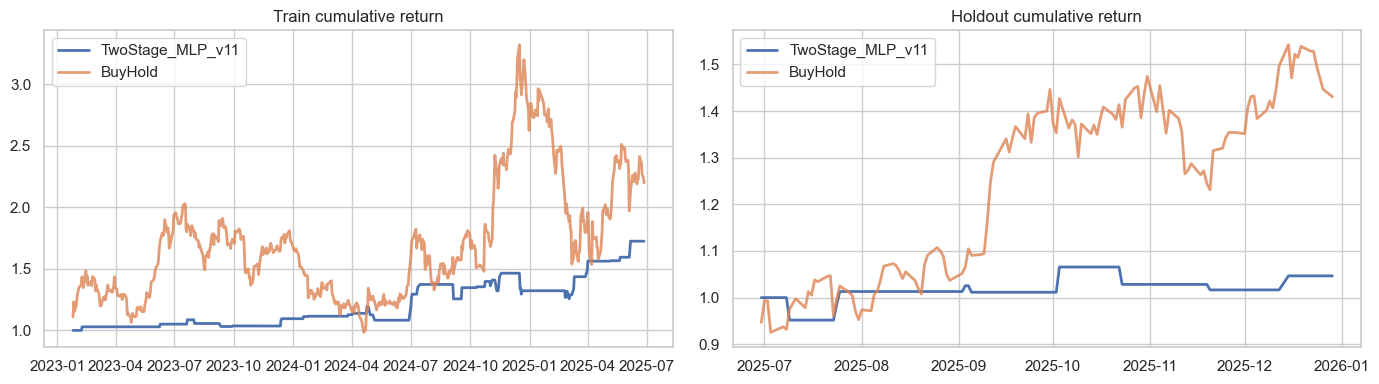

Saved search results to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_search_results.csv
Saved rolling results to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_rolling_window_results.csv
Saved metrics to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_metrics.csv
Saved test predictions to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_test_predictions.csv
Saved selected features to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_selected_features.csv


In [3]:
search_rows = []
config_counter = 0

print(f"Starting v11 rolling search with {configs_per_model} candidates")

for move_band in MOVE_BANDS:
    for top_k_move in TOP_K_MOVE:
        for top_k_dir in TOP_K_DIR:
            for hidden_layers in HIDDEN_CHOICES:
                for alpha_value in ALPHA_VALUES:
                    for learning_rate in LR_VALUES:
                        for move_prob_thr in MOVE_PROB_THRESHOLDS:
                            for dir_prob_thr in DIR_PROB_THRESHOLDS:
                                config_counter += 1
                                print(
                                    f"[Config {config_counter}/{configs_per_model}] "
                                    f"move_band={move_band}, top_k_move={top_k_move}, top_k_dir={top_k_dir}, "
                                    f"hidden={hidden_layers}, alpha={alpha_value}, lr={learning_rate}, "
                                    f"move_thr={move_prob_thr}, dir_thr={dir_prob_thr}"
                                )

                                window_stats = []
                                invalid = False

                                for window in rolling_windows:
                                    if window["window_id"] == 1 or window["window_id"] == len(rolling_windows) or window["window_id"] % 5 == 0:
                                        print(f"  window {window['window_id']}/{len(rolling_windows)}")

                                    tr = window["train_df"]
                                    te = window["test_df"]
                                    bundle = fit_two_stage_bundle(
                                        train_df=tr,
                                        feature_cols=model_features,
                                        move_band=move_band,
                                        top_k_move=top_k_move,
                                        top_k_dir=top_k_dir,
                                        hidden_layers=hidden_layers,
                                        alpha_value=alpha_value,
                                        learning_rate=learning_rate,
                                    )
                                    if bundle is None:
                                        invalid = True
                                        break

                                    sig, p_move, p_up = predict_two_stage(
                                        bundle,
                                        te,
                                        move_prob_thr=move_prob_thr,
                                        dir_prob_thr=dir_prob_thr,
                                    )
                                    strat_ret, trade_mask, sig_exec, true_dir, n_trades = backtest_from_signals(
                                        te["future_return_1d"].to_numpy(),
                                        sig,
                                        ONE_WAY_COST,
                                    )
                                    stats = perf_stats(strat_ret, trade_mask, sig_exec, n_trades)
                                    window_stats.append(stats)

                                if invalid or not window_stats:
                                    print("  no valid rolling result for this config")
                                    continue

                                mean_cum = float(np.mean([s["cum_return"] for s in window_stats]))
                                median_cum = float(np.median([s["cum_return"] for s in window_stats]))
                                mean_sharpe = float(np.mean([s["sharpe"] for s in window_stats]))
                                mean_active = float(np.mean([s["active_pct"] for s in window_stats]))
                                hit_values = [s["hit_rate_active"] for s in window_stats if not np.isnan(s["hit_rate_active"])]
                                mean_hit = float(np.mean(hit_values)) if hit_values else 0.5
                                profitable_pct = float(np.mean([s["cum_return"] > 0 for s in window_stats]))

                                score = (
                                    0.35 * mean_sharpe
                                    + 0.25 * median_cum
                                    + 0.20 * (profitable_pct - 0.5)
                                    + 0.20 * (mean_hit - 0.5)
                                )
                                if mean_active < MIN_ACTIVE_PCT:
                                    score -= 0.25

                                search_rows.append(
                                    {
                                        "move_band": move_band,
                                        "top_k_move": top_k_move,
                                        "top_k_dir": top_k_dir,
                                        "hidden_layers": str(tuple(hidden_layers)),
                                        "alpha_value": alpha_value,
                                        "learning_rate": learning_rate,
                                        "move_prob_thr": move_prob_thr,
                                        "dir_prob_thr": dir_prob_thr,
                                        "rolling_score": score,
                                        "rolling_mean_cum_return": mean_cum,
                                        "rolling_median_cum_return": median_cum,
                                        "rolling_mean_sharpe": mean_sharpe,
                                        "rolling_mean_active_pct": mean_active,
                                        "rolling_mean_hit_rate": mean_hit,
                                        "rolling_profitable_window_pct": profitable_pct,
                                        "n_windows": len(window_stats),
                                    }
                                )
                                print(
                                    f"  done: score={score:.4f}, mean_cum={mean_cum:.4f}, "
                                    f"mean_sharpe={mean_sharpe:.4f}, mean_active={mean_active:.4f}"
                                )

search_df = pd.DataFrame(search_rows).sort_values("rolling_score", ascending=False).reset_index(drop=True)
if search_df.empty:
    raise RuntimeError("No search results generated for v11")

search_path = output_dir / "stock_direction_v11_search_results.csv"
search_df.to_csv(search_path, index=False)
display(search_df.head(10))

best_cfg = search_df.iloc[0].to_dict()
print("Best v11 config:", best_cfg)

print("Re-running best v11 config across rolling windows...")
rolling_best_rows = []
for window in rolling_windows:
    if window["window_id"] == 1 or window["window_id"] == len(rolling_windows) or window["window_id"] % 5 == 0:
        print(f"  best-config window {window['window_id']}/{len(rolling_windows)}")

    tr = window["train_df"]
    te = window["test_df"]
    bundle = fit_two_stage_bundle(
        train_df=tr,
        feature_cols=model_features,
        move_band=float(best_cfg["move_band"]),
        top_k_move=int(best_cfg["top_k_move"]),
        top_k_dir=int(best_cfg["top_k_dir"]),
        hidden_layers=eval(best_cfg["hidden_layers"]),
        alpha_value=float(best_cfg["alpha_value"]),
        learning_rate=float(best_cfg["learning_rate"]),
    )
    sig, p_move, p_up = predict_two_stage(
        bundle,
        te,
        move_prob_thr=float(best_cfg["move_prob_thr"]),
        dir_prob_thr=float(best_cfg["dir_prob_thr"]),
    )
    strat_ret, trade_mask, sig_exec, true_dir, n_trades = backtest_from_signals(
        te["future_return_1d"].to_numpy(),
        sig,
        ONE_WAY_COST,
    )
    stats = perf_stats(strat_ret, trade_mask, sig_exec, n_trades)
    rolling_best_rows.append(
        {
            "window_id": window["window_id"],
            "train_start": str(window["train_start"].date()),
            "train_end": str(window["train_end"].date()),
            "test_start": str(window["test_start"].date()),
            "test_end": str(window["test_end"].date()),
            "move_rows_train": bundle["move_rows"],
            **stats,
        }
    )

rolling_best_df = pd.DataFrame(rolling_best_rows)
rolling_path = output_dir / "stock_direction_v11_rolling_window_results.csv"
rolling_best_df.to_csv(rolling_path, index=False)
display(rolling_best_df.head(10).round(4))

print("Fitting best v11 config on final training split...")
final_bundle = fit_two_stage_bundle(
    train_df=final_train_df,
    feature_cols=model_features,
    move_band=float(best_cfg["move_band"]),
    top_k_move=int(best_cfg["top_k_move"]),
    top_k_dir=int(best_cfg["top_k_dir"]),
    hidden_layers=eval(best_cfg["hidden_layers"]),
    alpha_value=float(best_cfg["alpha_value"]),
    learning_rate=float(best_cfg["learning_rate"]),
)

print("Scoring final train and holdout splits...")
sig_train, p_move_train, p_up_train = predict_two_stage(
    final_bundle,
    final_train_df,
    move_prob_thr=float(best_cfg["move_prob_thr"]),
    dir_prob_thr=float(best_cfg["dir_prob_thr"]),
)
sig_test, p_move_test, p_up_test = predict_two_stage(
    final_bundle,
    final_test_df,
    move_prob_thr=float(best_cfg["move_prob_thr"]),
    dir_prob_thr=float(best_cfg["dir_prob_thr"]),
)

train_strat_ret, train_trade_mask, train_sig_exec, train_true_dir, train_trades = backtest_from_signals(
    final_train_df["future_return_1d"].to_numpy(),
    sig_train,
    ONE_WAY_COST,
)
test_strat_ret, test_trade_mask, test_sig_exec, test_true_dir, test_trades = backtest_from_signals(
    final_test_df["future_return_1d"].to_numpy(),
    sig_test,
    ONE_WAY_COST,
)

buyhold_train = final_train_df.copy()
buyhold_train["signal"] = 1
buyhold_train["strategy_return"] = buyhold_train["future_return_1d"]
buyhold_train["trade_true_dir"] = np.where(buyhold_train["future_return_1d"] > 0, 1.0, 0.0)

buyhold_test = final_test_df.copy()
buyhold_test["signal"] = 1
buyhold_test["strategy_return"] = buyhold_test["future_return_1d"]
buyhold_test["trade_true_dir"] = np.where(buyhold_test["future_return_1d"] > 0, 1.0, 0.0)

metrics_rows = [
    {"model": "BuyHold", "split": "train", **perf_stats(buyhold_train["strategy_return"], np.ones(len(buyhold_train), dtype=bool), np.ones(len(buyhold_train), dtype=int), len(buyhold_train))},
    {"model": "BuyHold", "split": "test", **perf_stats(buyhold_test["strategy_return"], np.ones(len(buyhold_test), dtype=bool), np.ones(len(buyhold_test), dtype=int), len(buyhold_test))},
    {"model": "TwoStage_MLP_v11", "split": "train", **perf_stats(train_strat_ret, train_trade_mask, train_sig_exec, train_trades)},
    {"model": "TwoStage_MLP_v11", "split": "test", **perf_stats(test_strat_ret, test_trade_mask, test_sig_exec, test_trades)},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_path = output_dir / "stock_direction_v11_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

test_predictions = final_test_df[["date", "future_return_1d", "y_dir"]].copy()
test_predictions["p_move"] = p_move_test
test_predictions["p_up"] = p_up_test
test_predictions["signal"] = sig_test
test_predictions["trade_executed"] = test_trade_mask
test_predictions["strategy_return"] = test_strat_ret
test_predictions["trade_true_dir"] = test_true_dir
pred_path = output_dir / "stock_direction_v11_test_predictions.csv"
test_predictions.to_csv(pred_path, index=False)

feature_rows = []
for stage_name, cols, rank_df in [
    ("move", final_bundle["move_cols"], final_bundle["move_rank"]),
    ("direction", final_bundle["dir_cols"], final_bundle["dir_rank"]),
]:
    for rank, feature in enumerate(cols, start=1):
        mi_value = np.nan
        if not rank_df.empty:
            match = rank_df.loc[rank_df["feature"] == feature, "mi"]
            if not match.empty:
                mi_value = float(match.iloc[0])
        feature_rows.append(
            {
                "stage": stage_name,
                "feature": feature,
                "selected_rank": rank,
                "mi_score": mi_value,
                "hidden_layers": best_cfg["hidden_layers"],
                "alpha_value": float(best_cfg["alpha_value"]),
                "learning_rate": float(best_cfg["learning_rate"]),
            }
        )
selected_features_df = pd.DataFrame(feature_rows)
selected_features_path = output_dir / "stock_direction_v11_selected_features.csv"
selected_features_df.to_csv(selected_features_path, index=False)

display(metrics_df.round(4))
display(selected_features_df)

print("Preparing classification report and plots...")
active_test = test_predictions[test_predictions["signal"] != 0].copy()
if len(active_test):
    y_true_active = active_test["trade_true_dir"].astype(int)
    y_pred_active = np.where(active_test["signal"] == 1, 1, 0)
    print("Classification report on active trades:")
    print(classification_report(y_true_active, y_pred_active, digits=4))
else:
    print("No active trades on the final holdout.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_equity = np.cumprod(1 + train_strat_ret)
test_equity = np.cumprod(1 + test_strat_ret)
buyhold_train_equity = np.cumprod(1 + final_train_df["future_return_1d"].to_numpy())
buyhold_test_equity = np.cumprod(1 + final_test_df["future_return_1d"].to_numpy())

axes[0].plot(final_train_df["date"], train_equity, label="TwoStage_MLP_v11", linewidth=2)
axes[0].plot(final_train_df["date"], buyhold_train_equity, label="BuyHold", linewidth=2, alpha=0.8)
axes[0].set_title("Train cumulative return")
axes[0].legend()

axes[1].plot(final_test_df["date"], test_equity, label="TwoStage_MLP_v11", linewidth=2)
axes[1].plot(final_test_df["date"], buyhold_test_equity, label="BuyHold", linewidth=2, alpha=0.8)
axes[1].set_title("Holdout cumulative return")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Saved search results to {search_path}")
print(f"Saved rolling results to {rolling_path}")
print(f"Saved metrics to {metrics_path}")
print(f"Saved test predictions to {pred_path}")
print(f"Saved selected features to {selected_features_path}")